# sEEG EDF file viewer (Google Colab)

This notebook loads `dataset/sEEG-HFOs-8.edf`, displays its recording and channel metadata, provides an interactive channel/time viewer, and plots a power spectrum. Run the cells from top to bottom in Google Colab.

> Colab runs Linux, so a local path written as `\dataset\sEEG-HFOs-8.edf` should be uploaded or mounted at `/content/dataset/sEEG-HFOs-8.edf`.

## Общее описание записи

Это **интракраниальная стерео-ЭЭГ (sEEG)** — запись с глубинных многоконтактных электродов, введённых стереотаксически через фрезевые отверстия. В перечне:

- **100 энцефалографических каналов** (контакты 12 глубинных электродов) + **2 маркерных канала** (MKR1+, MKR2+) = **102 канала**;
- **7 электродов без штриха** (R, FP, FD, PM, CC, SA, PA) — одно полушарие;
- **5 электродов со штрихом** (PM′, CC′, SA′, PA′, CR′) — зеркальные (гомологичные) электроды **противоположного полушария** (штрих — общепринятое обозначение контрлатеральной стороны);
- передняя лобная группа (R, FP, FD) имплантирована **односторонне**;
- MKR1+/MKR2+ — технические каналы событий/стимуляции (или физиологические маркеры), «+» — полярность входа, к анализу ЭЭГ отношения не имеют.

| Электрод | Контактов | Предполагаемая зона покрытия |
|---|---|---|
| R | 10 | ростральный/передний лобный отдел (реже так обозначают референсный электрод — уточнить по плану) |
| FP | 8 | фронтополярная кора (БА 10) |
| FD | 6 | дорсальная лобная область (верхняя лобная извилина) |
| PM | 8 | премоторная кора (задние отделы средней/верхней лобной извилины, БА 6) |
| CC | 10 | центральная область — прецентральная извилина, моторная кора (БА 4) |
| SA | 6 | соматосенсорная кора — постцентральная извилина (БА 3-1-2) |
| PA | 10 | теменная доля (верхняя/нижняя теменные дольки) |
| PM′ / CC′ / SA′ / PA′ | 6/10/8/8 | те же зоны противоположного полушария |
| CR′ | 10 | поясная извилина (цингулярная кора, медиальная поверхность) |

Монтаж — **двустороннее покрытие периrolандической и теменной сети** (моторная + сенсорная + теменная + поясная кора) плюс односторонний лобный «фронт». Такой план типичен для оценки эпи­лепсии с центральнотеменной/периrolандической локализацией и для функционального картирования перед резекцией вблизи эло­квентной коры.

In [1]:
# Install the EDF reader and interactive controls in the Colab runtime.
%pip install -q mne edfio ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import display

mne.set_log_level("WARNING")
plt.rcParams.update({"figure.figsize": (14, 7), "axes.grid": True})

## Locate the EDF file

The first path below is the expected Colab location. If the dataset is on your computer instead, open Colab's **Files** panel, create a `dataset` folder, and upload the EDF file into it. Alternatively, uncomment and run the upload snippet; uploaded files are temporary and disappear when the runtime resets.

In [3]:
# Optional browser upload (uncomment only if the file is not in /content/dataset).
# from google.colab import files
# uploaded = files.upload()
# Path("/content/dataset").mkdir(parents=True, exist_ok=True)
# uploaded_name = next(iter(uploaded))
# Path(uploaded_name).replace(Path("/content/dataset/sEEG-HFOs-8.edf"))

In [4]:
candidates = [
    Path("/content/sEEG-HFOs-8.edf"),  # Google Colab
    #Path("dataset/sEEG-HFOs-8.edf"),           # local Jupyter / repository
]
edf_path = next((path for path in candidates if path.is_file()), None)
if edf_path is None:
    searched = "\n".join(f"  - {path.resolve()}" for path in candidates)
    raise FileNotFoundError(
        "sEEG-HFOs-8.edf was not found. Upload it with the cell above. "
        f"Searched:\n{searched}"
    )

print(f"Loading: {edf_path.resolve()}")
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING")
print("EDF loaded successfully.")

Loading: /content/sEEG-HFOs-8.edf


/tmp/ipykernel_606/2175274556.py:14: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING")
/tmp/ipykernel_606/2175274556.py:14: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING")


EDF loaded successfully.


## Recording and channel information

In [5]:
duration_s = raw.n_times / raw.info["sfreq"]
summary = pd.Series({
    "File": str(edf_path),
    "Channels": raw.info["nchan"],
    "Sampling frequency (Hz)": raw.info["sfreq"],
    "Samples per channel": raw.n_times,
    "Duration (seconds)": duration_s,
    "Duration (HH:MM:SS)": pd.to_timedelta(duration_s, unit="s"),
    "Start time": raw.info["meas_date"],
})
display(summary.to_frame("Value"))

channel_table = pd.DataFrame({
    "index": np.arange(len(raw.ch_names)),
    "name": raw.ch_names,
    "type": raw.get_channel_types(),
})
display(channel_table)

,Value
File,/content/sEEG-HFOs-8.edf
Channels,102
Sampling frequency (Hz),256.0
Samples per channel,529152
Duration (seconds),2067.0
Duration (HH:MM:SS),0 days 00:34:27
Start time,2019-01-01 01:00:00+00:00


,index,name,type
0,0,EEG R1,eeg
1,1,EEG R2,eeg
2,2,EEG R3,eeg
3,3,EEG R4,eeg
4,4,EEG R5,eeg
...,...,...,...
97,97,EEG PA'5,eeg
98,98,EEG PA'6,eeg
99,99,EEG PA'7,eeg
100,100,EEG PA'8,eeg


## Interactive signal viewer

Select one or more channels and move the time slider. Signals are displayed in microvolts and vertically separated. The viewer reads only the selected segment, which keeps large EDF files manageable.

In [10]:
default_channels = tuple(raw.ch_names[: min(8, len(raw.ch_names))])
channel_picker = widgets.SelectMultiple(
    options=raw.ch_names, value=default_channels, description="Channels",
    rows=min(12, len(raw.ch_names)), layout=widgets.Layout(width="45%"),
)
window_picker = widgets.Dropdown(
    options=[1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 300.0, 1000.0], value=10.0,
    description="Window (s)",
)
start_picker = widgets.FloatSlider(
    value=0.0, min=0.0, max=max(0.0, duration_s - window_picker.value),
    step=max(0.1, min(1.0, duration_s / 1000)), description="Start (s)",
    continuous_update=False, readout_format=".1f",
    layout=widgets.Layout(width="90%"),
)

def update_slider_range(change=None):
    start_picker.max = max(0.0, duration_s - window_picker.value)
    start_picker.value = min(start_picker.value, start_picker.max)

window_picker.observe(update_slider_range, names="value")

def plot_segment(channels, start, window):
    if not channels:
        print("Select at least one channel.")
        return
    stop = min(start + window, duration_s)
    data, times = raw.get_data(picks=list(channels), tmin=start, tmax=stop, return_times=True)
    data_uv = data * 1e6
    robust_span = np.nanpercentile(np.abs(data_uv), 95)
    spacing = max(1.0, 2.5 * robust_span)
    offsets = np.arange(len(channels))[::-1] * spacing

    fig, ax = plt.subplots(figsize=(15, max(4, 0.55 * len(channels))))
    for signal, offset, name in zip(data_uv, offsets, channels):
        ax.plot(times, signal + offset, linewidth=0.7, label=name)
    ax.set_yticks(offsets, labels=channels)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Channel (signals offset; amplitude in µV)")
    ax.set_title(f"sEEG: {start:.2f}–{stop:.2f} s")
    ax.margins(x=0)
    plt.show()

controls = {"channels": channel_picker, "start": start_picker, "window": window_picker}
viewer = widgets.interactive_output(plot_segment, controls)
display(widgets.VBox([channel_picker, window_picker, start_picker]), viewer)

Output()

## Power spectral density

Run this cell after choosing channels and a time window above. The upper frequency is limited by both 250 Hz and the recording's Nyquist frequency.

/tmp/ipykernel_606/1083026417.py:12: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  spectrum.plot(average=False, amplitude=False, picks=selected_channels)


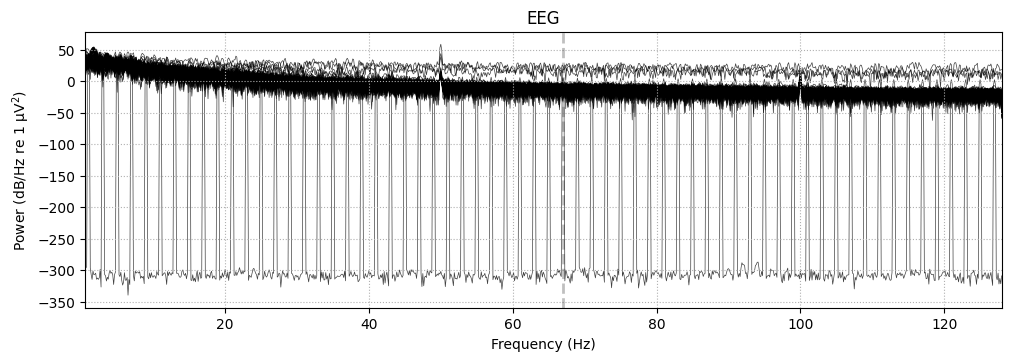

In [7]:
selected_channels = list(channel_picker.value)
if not selected_channels:
    raise ValueError("Select at least one channel in the viewer first.")

tmin = start_picker.value
tmax = min(tmin + window_picker.value, duration_s)
fmax = min(250.0, raw.info["sfreq"] / 2.0)
spectrum = raw.compute_psd(
    method="welch", picks=selected_channels, tmin=tmin, tmax=tmax,
    fmin=0.5, fmax=fmax, verbose="WARNING",
)
spectrum.plot(average=False, amplitude=False, picks=selected_channels)
plt.show()

## Optional: export a selected segment

The following example creates a new in-memory MNE object containing the current selection. Uncomment the last line to save it in MNE's lossless FIF format.

In [8]:
segment = raw.copy().pick(list(channel_picker.value)).crop(
    tmin=start_picker.value,
    tmax=min(start_picker.value + window_picker.value, duration_s),
).load_data()
print(segment)
# segment.save("selected_seeg_segment_raw.fif", overwrite=True)

<RawEDF | sEEG-HFOs-8.edf, 101 x 2561 (10.0 s), ~2.1 MiB, data loaded>


In [11]:
print(channel_table['name'].to_list())

['EEG R1', 'EEG R2', 'EEG R3', 'EEG R4', 'EEG R5', 'EEG R6', 'EEG R7', 'EEG R8', 'EEG R9', 'EEG R10', 'EEG FP1', 'EEG FP2', 'EEG FP3', 'EEG FP4', 'EEG FP5', 'EEG FP6', 'EEG FP7', 'EEG FP8', 'EEG FD1', 'EEG FD2', 'EEG FD3', 'EEG FD4', 'EEG FD5', 'EEG FD6', 'EEG PM1', 'EEG PM2', 'EEG PM3', 'EEG PM4', 'EEG PM5', 'EEG PM6', 'EEG PM7', 'EEG PM8', 'EEG CC1', 'EEG CC2', 'EEG CC3', 'EEG CC4', 'EEG CC5', 'EEG CC6', 'EEG CC7', 'EEG CC8', 'EEG CC9', 'EEG CC10', 'EEG SA1', 'EEG SA2', 'EEG SA3', 'EEG SA4', 'EEG SA5', 'EEG SA6', 'EEG PA1', 'EEG PA2', 'EEG PA3', 'EEG PA4', 'EEG PA5', 'EEG PA6', 'EEG PA7', 'EEG PA8', 'EEG PA9', 'EEG PA10', "EEG CR'1", "EEG CR'2", "EEG CR'3", "EEG CR'4", "EEG CR'5", "EEG CR'6", 'MKR1+', "EEG CR'7", "EEG CR'8", "EEG CR'9", "EEG CR'10", "EEG CC'1", "EEG CC'2", "EEG CC'3", "EEG CC'4", "EEG CC'5", "EEG CC'6", "EEG CC'7", "EEG CC'8", "EEG CC'9", "EEG CC'10", "EEG PM'1", "EEG PM'2", "EEG PM'3", "EEG PM'4", "EEG PM'5", "EEG PM'6", "EEG SA'1", "EEG SA'2", "EEG SA'3", "EEG SA'4